# FIT5196 Assignment 2 - Task 2: Data Reshaping, Feature Engineering, and Advanced Analysis

**Group 032**

**Date:** October 2025

---

## 任务概述与评分点（Task 2: Data Reshaping, 9/40）

本笔记用于完成 Task 2 的“数据整形/特征工程与分析（仅为线性回归做准备，不训练模型）”。我们将：

- 加载 suburb_info.xlsx 并理解字段含义
- EDA：目标变量与特征的分布、异常/离群、尺度差异、与目标的线性关系与相关性
- 规范化/变换：标准化、Min-Max、Robust 以及对偏态的对数/平方根/Box-Cox/Yeo-Johnson 变换
- 评价：是否让特征处于同一量纲、是否提升与目标的线性关系、线性回归四大假设的准备程度
- 文档化：记录每一步的动机、方法与可视化/定量证据，最后给出推荐方案

评分点提醒：需要清晰结构、合理解释与注释（中文），展示探索过程与中间结果。

## 1. 环境与库导入（Imports & Setup）
.
说明：以下代码将导入常用数据分析与可视化库，并设置图形风格。如缺少库，会尝试自动安装一次（仅限本环境）。

In [31]:
# 如果某些依赖缺失，尝试自动安装一次；失败则提示用户手动安装
def _ensure(package, import_name=None):
    import importlib, sys, subprocess
    name = import_name or package
    try:
        importlib.import_module(name)
        return True
    except Exception:
        try:
            print(f"尝试安装: {package} …")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            importlib.import_module(name)
            return True
        except Exception as e:
            print(f"安装 {package} 失败：{e}")
            return False

_ensure("pandas")
_ensure("numpy")
_ensure("matplotlib")
_ensure("seaborn")
_ensure("scikit-learn", "sklearn")
_ensure("scipy")
_ensure("openpyxl")  # 读取 Excel

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox, yeojohnson
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler



# 统一显示/绘图风格
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
print("环境准备完成。版本：",
      {
          'pandas': pd.__version__,
          'numpy': np.__version__,
          'seaborn': sns.__version__,
      })

环境准备完成。版本： {'pandas': '2.3.1', 'numpy': '2.3.1', 'seaborn': '0.13.2'}


In [32]:
# 解决中文字体缺失导致的警告/乱码问题
from matplotlib import font_manager as _fm
_candidates = [
    'PingFang SC', 'Hiragino Sans GB', 'Heiti TC', 'Songti SC', 'STHeiti',
    'Arial Unicode MS', 'Noto Sans CJK SC', 'SimHei', 'Microsoft YaHei', 'WenQuanYi Zen Hei'
 ]
_avail = {f.name for f in _fm.fontManager.ttflist}
_chosen = None
for _name in _candidates:
    if _name in _avail:
        _chosen = _name
        break
if _chosen:
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = [_chosen]
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    print(f'已设置中文字体: {_chosen}')
else:
    # 兜底：使用 DejaVu Sans（不完全覆盖），并给出安装建议提示
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    print('未检测到常见中文字体，可能仍有缺字。建议安装 Noto Sans CJK 或启用系统中文字体。')

已设置中文字体: Hiragino Sans GB


## 2. 数据加载与理解（Data Loading & Understanding）
.
说明：将尝试定位并加载 `suburb_info.xlsx`。如果文件不在默认目录，将提示手动设置路径。

In [33]:
# 读取数据
df = pd.read_excel('suburb_info.xlsx', engine='openpyxl')
print(f"数据读取成功，形状: {df.shape}")

数据读取成功，形状: (202, 8)


### 2.1 字段检查与基本信息
.
说明：查看数据类型、缺失值情况、重复情况，确认关键列是否存在。

In [34]:
if df is not None:
    print('列名:', list(df.columns))
    print('\n数据类型:')
    display(df.dtypes)
    print('\n缺失值统计:')
    display(df.isna().sum().to_frame('missing'))
    # 重复检查（按索引与整行）
    if df.index.name is not None:
        print(f"索引（{df.index.name}）是否唯一:", df.index.is_unique)
    print('重复行数量:', df.duplicated().sum())
    print('\n描述性统计:')
    display(df.describe(include='all'))
else:
    print('df 为空，请先修正数据路径后重试。')

列名: ['suburb', 'number_of_houses', 'number_of_units', 'municipality', 'aus_born_perc', 'median_income', 'median_house_price', 'population']

数据类型:


suburb                object
number_of_houses       int64
number_of_units        int64
municipality          object
aus_born_perc         object
median_income         object
median_house_price    object
population             int64
dtype: object


缺失值统计:


,missing
suburb,0
number_of_houses,0
number_of_units,0
municipality,0
aus_born_perc,0
median_income,0
median_house_price,0
population,0


重复行数量: 0

描述性统计:


,suburb,number_of_houses,number_of_units,municipality,aus_born_perc,median_income,median_house_price,population
count,202,202.000000,202.000000,202,202,202,202,202.000000
unique,202,NaN,NaN,28,40,129,201,NaN
top,ABBOTSFORD,NaN,NaN,Banyule,77%,"$1,538","$1,047,100",NaN
freq,1,NaN,NaN,15,12,5,2,NaN
mean,NaN,4155.767327,2480.410891,NaN,NaN,NaN,NaN,18659.311881
std,NaN,3400.864988,3132.684712,NaN,NaN,NaN,NaN,9604.187282
min,NaN,283.000000,60.000000,NaN,NaN,NaN,NaN,170.000000
25%,NaN,1973.500000,620.500000,NaN,NaN,NaN,NaN,12063.000000
50%,NaN,3256.500000,1603.000000,NaN,NaN,NaN,NaN,17583.000000
75%,NaN,5518.500000,3089.000000,NaN,NaN,NaN,NaN,24045.000000


### 2.2 数据清洗与类型转换
.
观察到以下列为 object 类型：`aus_born_perc`, `median_income`, `median_house_price`。通常是带有符号（如 %、$、逗号）造成。下面将转换为数值型以便分析。

In [35]:
def to_numeric_clean(s: pd.Series):
    # 去除 $, 逗号, 百分号等常见符号
    return (s.astype(str)
              .str.replace('[\$,]', '', regex=True)
              .str.replace('%', '', regex=False)
              .str.strip()
              .replace({'': np.nan, 'NA': np.nan, 'NaN': np.nan})
              .astype(float))

if df is not None:
    for col in ['aus_born_perc','median_income','median_house_price']:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = to_numeric_clean(df[col])
    print('类型转换完成。当前数据类型：')
    display(df.dtypes)

类型转换完成。当前数据类型：


suburb                 object
number_of_houses        int64
number_of_units         int64
municipality           object
aus_born_perc         float64
median_income         float64
median_house_price    float64
population              int64
dtype: object

## 3. EDA：分布、尺度与相关性
.
说明：
- 目标变量：`median_house_price` 的分布、离群值
- 特征：`aus_born_perc`, `number_of_units`, `number_of_houses`, `population`, `median_income` 的分布与尺度
- 相关性：与目标的 Pearson/Spearman 相关；散点/回归线查看线性趋势

用于分析的列: ['median_house_price', 'aus_born_perc', 'number_of_units', 'number_of_houses', 'population', 'median_income']


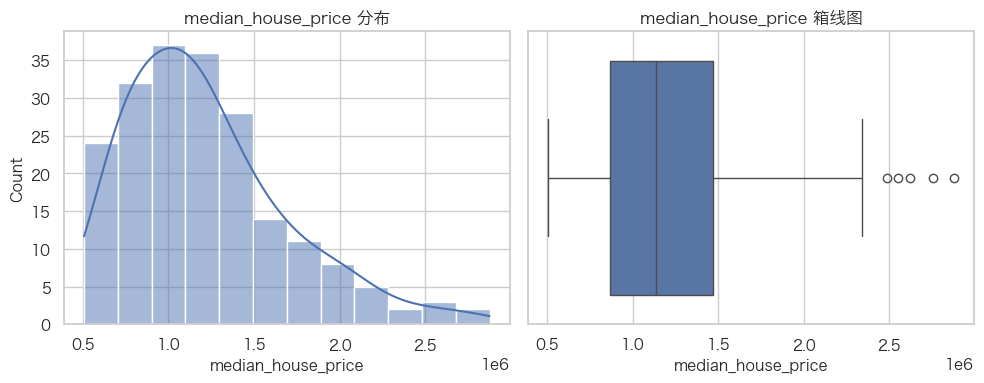

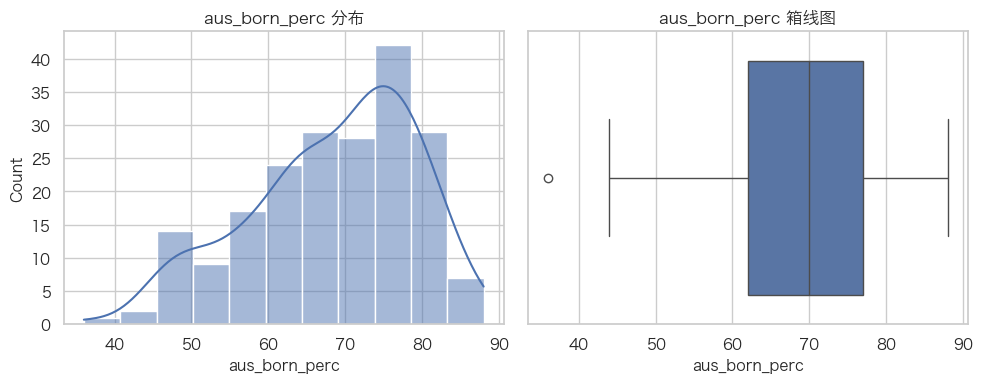

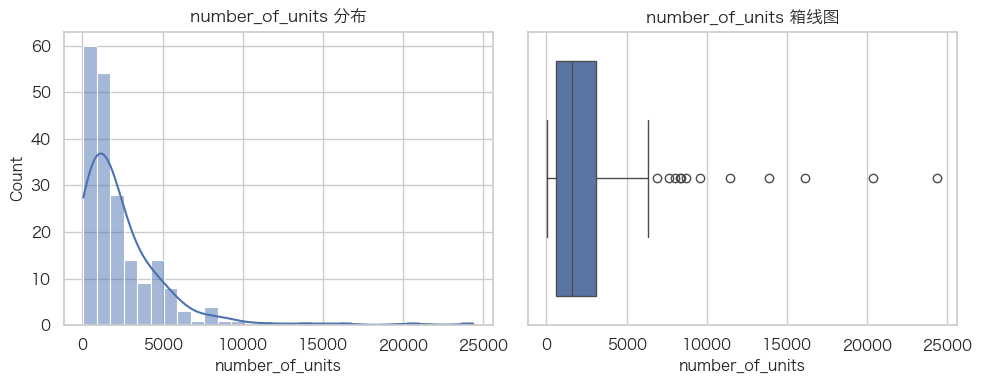

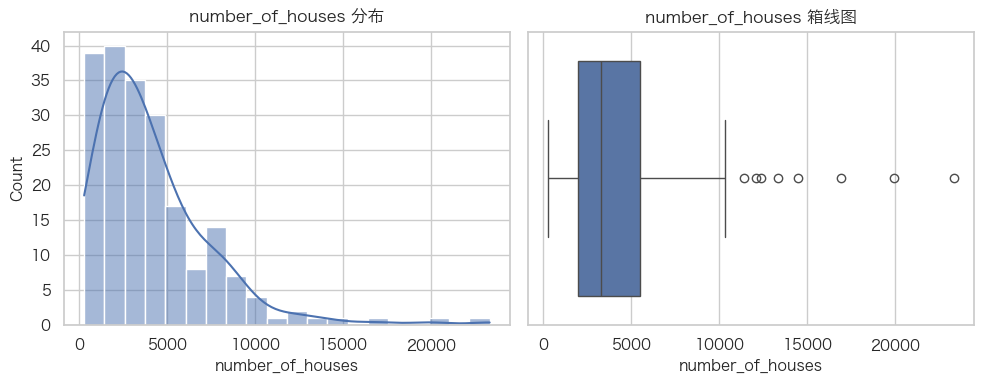

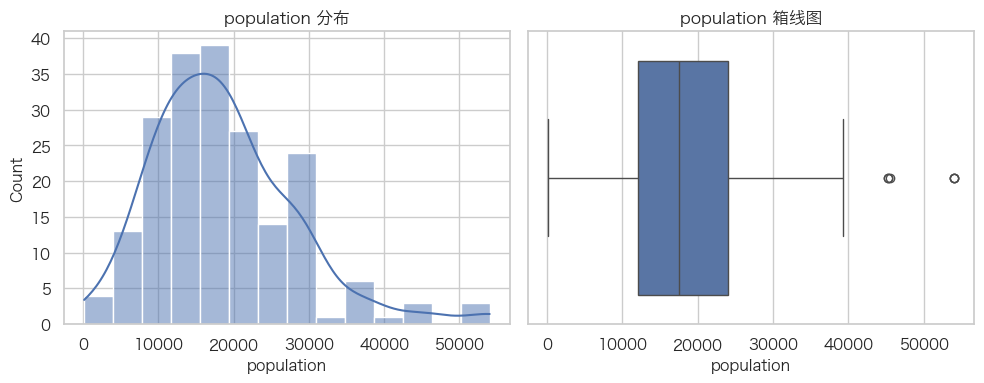

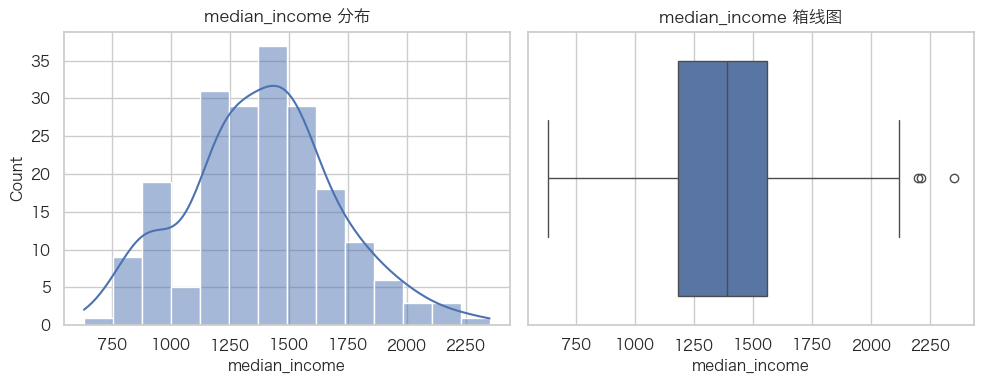

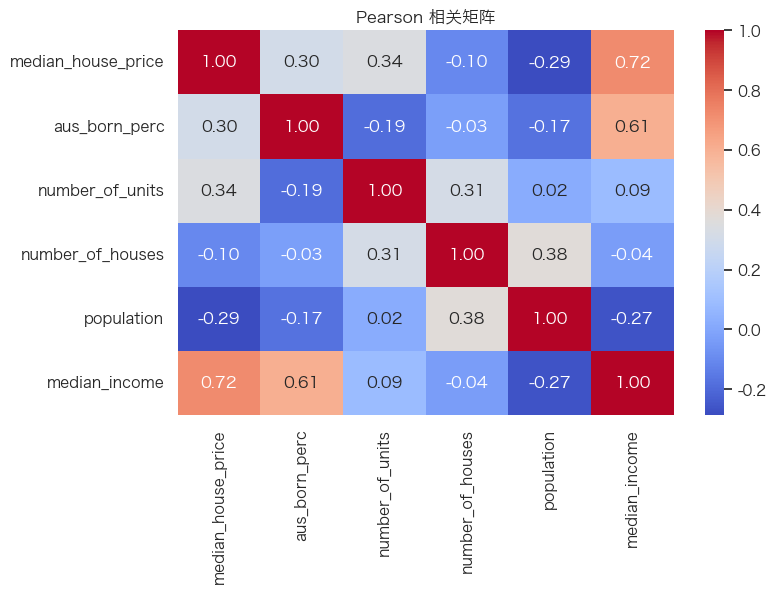

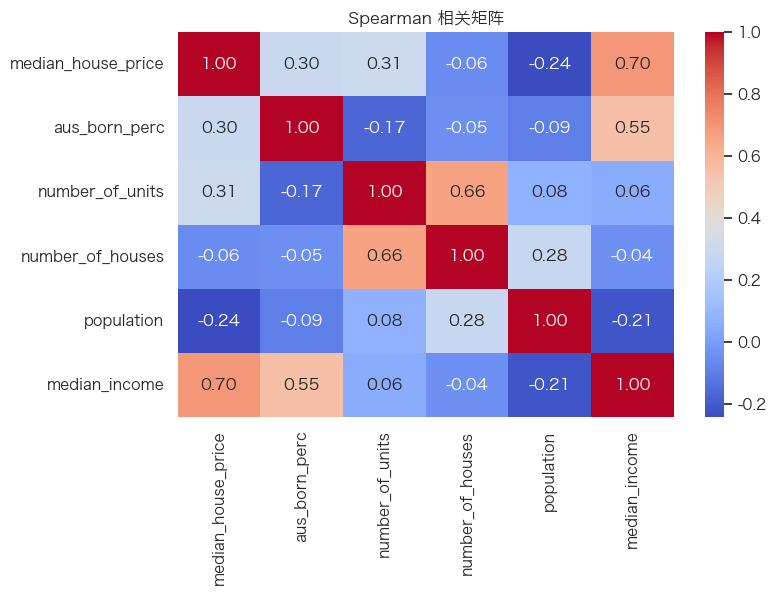

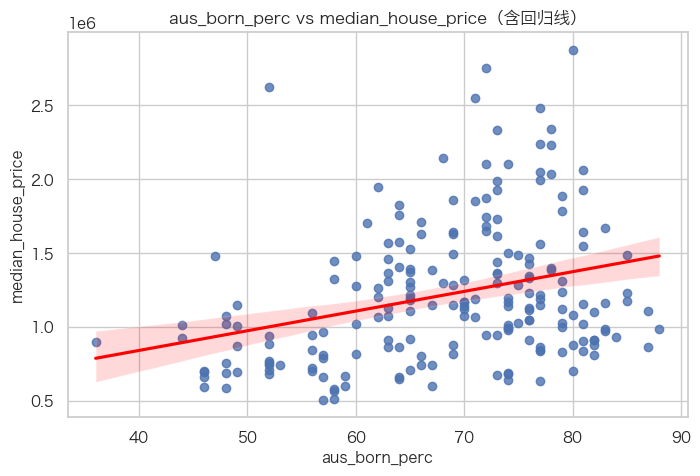

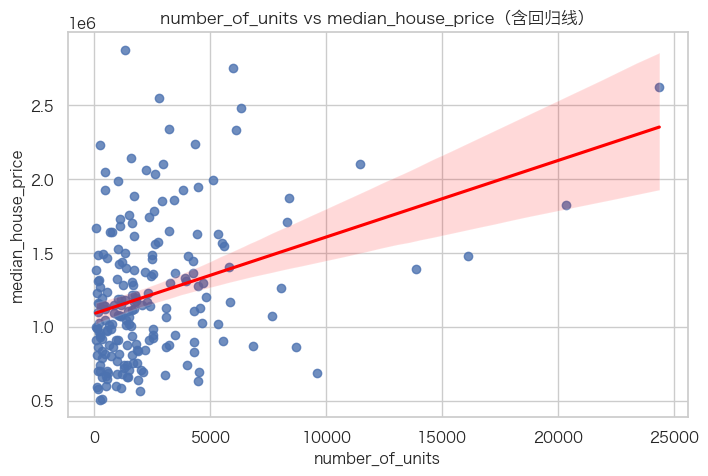

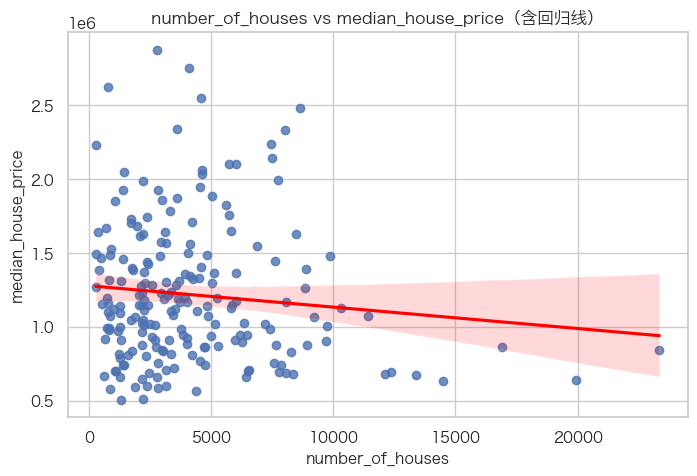

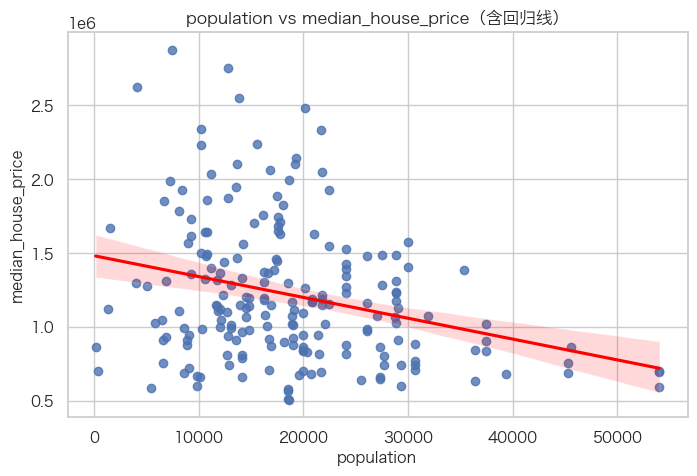

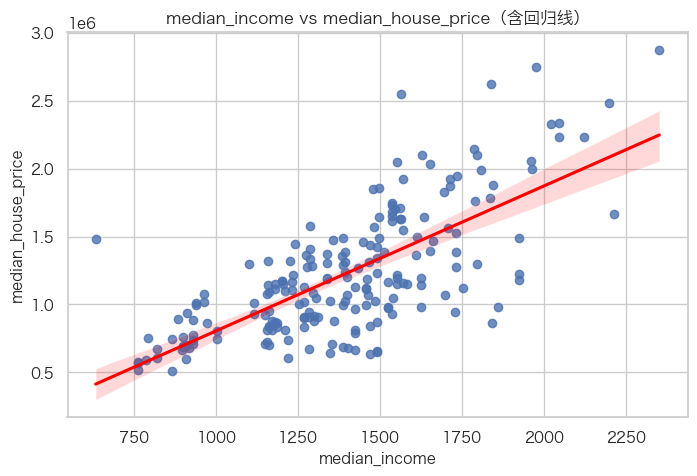

In [36]:
if df is not None:
    target = 'median_house_price'
    features = ['aus_born_perc', 'number_of_units', 'number_of_houses', 'population', 'median_income']
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    # 仅保留分析所需列存在的情况
    cols_exist = [c for c in [target] + features if c in df.columns]
    print('用于分析的列:', cols_exist)

    # 分布直方图 + KDE
    for col in cols_exist:
        fig, axes = plt.subplots(1, 2, figsize=(10,4))
        sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
        axes[0].set_title(f'{col} 分布')
        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f'{col} 箱线图')
        plt.tight_layout()
        plt.show()

    # 相关性矩阵（数值列）
    corr_cols = [c for c in cols_exist if c in numeric_cols]
    if len(corr_cols) >= 2:
        corr = df[corr_cols].corr(method='pearson')
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Pearson 相关矩阵')
        plt.show()
        corr_s = df[corr_cols].corr(method='spearman')
        sns.heatmap(corr_s, annot=True, cmap='coolwarm', fmt='.2f')
        plt.title('Spearman 相关矩阵')
        plt.show()

    # 与目标的散点+回归线
    if target in df.columns:
        for f in features:
            if f in df.columns:
                sns.regplot(x=df[f], y=df[target], line_kws={'color':'red'})
                plt.title(f'{f} vs {target}（含回归线）')
                plt.show()
else:
    print('df 为空，请先修正数据路径后重试。')

## 4. 缩放（Scaling）与变换（Transformation）设计
.
说明：
- 缩放：StandardScaler、MinMaxScaler、RobustScaler（处理不同量纲与潜在离群）
- 变换：log1p、sqrt、Box-Cox（>0）、Yeo-Johnson（可含负数）以缓解偏态并改善与目标的线性关系。
.
比较策略：对每个特征（以及可选的目标）在不同方案下计算与目标的相关系数、偏度/峰度变化；绘图对比。

### 4.1 缩放效果摘要（同量纲性对比）
.
通过对比原始特征与三种缩放器（Standard/Min-Max/Robust）后的统计值，观察是否满足“同一量纲”的目标。

In [37]:
if df is not None:
    features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    base_stats = df[features].describe().loc[['mean','std','min','25%','50%','75%','max']]
    print('原始特征统计：')
    display(base_stats)

    # 若上游尚未计算 scaled_views，则在此临时计算一次，避免 NameError
    def _compute_scaled_views(_df, _features):
        scalers = {
            'standard': StandardScaler(),
            'minmax': MinMaxScaler(),
            'robust': RobustScaler(),
        }
        scaled_local = {}
        X = _df[_features].copy()
        for name, scaler in scalers.items():
            try:
                arr = scaler.fit_transform(X.fillna(X.median()))
                scaled_local[name] = pd.DataFrame(arr, index=X.index, columns=X.columns)
            except Exception as e:
                print(f'缩放 {name} 失败: {e}')
                scaled_local[name] = None
        return scaled_local

    _views = globals().get('scaled_views')
    if _views is None:
        _views = _compute_scaled_views(df, features)

    for name, view in (_views or {}).items():
        if view is None:
            continue
        print(f'缩放器 {name} 的统计：')
        display(view[features].describe().loc[['mean','std','min','25%','50%','75%','max']])

原始特征统计：


,aus_born_perc,number_of_units,number_of_houses,population,median_income
mean,68.366337,2480.410891,4155.767327,18659.311881,1387.935644
std,10.761293,3132.684712,3400.864988,9604.187282,317.841321
min,36.000000,60.000000,283.000000,170.000000,633.000000
25%,62.000000,620.500000,1973.500000,12063.000000,1182.250000
50%,70.000000,1603.000000,3256.500000,17583.000000,1393.000000
75%,77.000000,3089.000000,5518.500000,24045.000000,1560.000000
max,88.000000,24380.000000,23338.000000,54005.000000,2352.000000


缩放器 standard 的统计：


,aus_born_perc,number_of_units,number_of_houses,population,median_income
mean,2.638154e-17,-6.595384e-17,-1.192665e-16,1.159688e-16,-1.934646e-16
std,1.002484e+00,1.002484e+00,1.002484e+00,1.002484e+00,1.002484e+00
min,-3.015135e+00,-7.745511e-01,-1.141589e+00,-1.929913e+00,-2.381098e+00
25%,-5.930657e-01,-5.951865e-01,-6.432743e-01,-6.885226e-01,-6.487409e-01
50%,1.521864e-01,-2.807786e-01,-2.650801e-01,-1.123454e-01,1.597319e-02
75%,8.042819e-01,1.947534e-01,4.016973e-01,5.621578e-01,5.426980e-01
max,1.829004e+00,7.008046e+00,5.654412e+00,3.689381e+00,3.040698e+00


缩放器 minmax 的统计：


,aus_born_perc,number_of_units,number_of_houses,population,median_income
mean,0.622430,0.099523,0.167979,0.343444,0.439171
std,0.206948,0.128811,0.147511,0.178400,0.184899
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.023047,0.073325,0.220916,0.319517
50%,0.653846,0.063446,0.128974,0.323451,0.442118
75%,0.788462,0.124548,0.227087,0.443485,0.539267
max,1.000000,1.000000,1.000000,1.000000,1.000000


缩放器 robust 的统计：


,aus_born_perc,number_of_units,number_of_houses,population,median_income
mean,-0.108911,0.355443,0.253672,0.089827,-0.013407
std,0.717420,1.269064,0.959341,0.801551,0.841407
min,-2.266667,-0.625076,-0.838787,-1.453263,-2.011913
25%,-0.533333,-0.398015,-0.361918,-0.460691,-0.557909
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.466667,0.601985,0.638082,0.539309,0.442091
max,1.200000,9.227061,5.664739,3.039726,2.538716


In [38]:
def try_boxcox(series):
    # 仅当所有值 > 0 时可用；返回变换后的值与 lambda
    s = series.dropna()
    if (s <= 0).any():
        return None, None
    try:
        y, lmbda = boxcox(s)
        out = pd.Series(index=s.index, data=y)
        return out.reindex(series.index), lmbda
    except Exception:
        return None, None

def apply_transforms(df, features, target):
    X = df[features].copy()
    y = df[target] if target in df.columns else None

    results = {}  # 每个特征的不同变换结果
    for col in features:
        s = X[col]
        transforms = {}
        transforms['identity'] = s
        transforms['log1p'] = np.log1p(s.clip(lower=0)) if pd.api.types.is_numeric_dtype(s) else None
        transforms['sqrt'] = np.sqrt(s.clip(lower=0)) if pd.api.types.is_numeric_dtype(s) else None
        bc, lmbda = try_boxcox(s)
        transforms['boxcox'] = bc
        transforms['yeojohnson'] = pd.Series(yeojohnson(s.dropna())[0], index=s.dropna().index).reindex(s.index) if pd.api.types.is_numeric_dtype(s) else None

        results[col] = transforms

    # 缩放器（用于整体量纲统一的演示）
    scalers = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler(),
    }
    scaled = {}
    for name, scaler in scalers.items():
        try:
            arr = scaler.fit_transform(X.fillna(X.median()))
            scaled[name] = pd.DataFrame(arr, index=X.index, columns=X.columns)
        except Exception as e:
            print(f'缩放 {name} 失败: {e}')
            scaled[name] = None

    return results, scaled

if df is not None:
    target = 'median_house_price'
    features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    X_trans, scaled_views = apply_transforms(df, features, target)
    print('已计算特征的多种变换与缩放版本。可视化与评估见下节。')
else:
    print('df 为空，请先修正数据路径后重试。')

已计算特征的多种变换与缩放版本。可视化与评估见下节。


## 5. 评估：偏度/峰度与相关性的改进
+
说明：
- 统计每个特征在不同变换后的偏度（skew）与与目标的 Pearson 相关系数
- 用表格展示“是否更接近正态/是否提升线性相关”

In [39]:
if df is not None and 'median_house_price' in df.columns:
    target = 'median_house_price'
    features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    stats_rows = []
    for col in features:
        transforms = X_trans.get(col, {})
        for tf, series in transforms.items():
            if series is None:
                continue
            s = series.dropna()
            y = df.loc[s.index, target].dropna()
            common = s.index.intersection(y.index)
            if common.empty:
                continue
            pearson = np.corrcoef(s.loc[common], y.loc[common])[0,1] if len(common) > 2 else np.nan
            skew = stats.skew(s.loc[common], bias=False) if len(common) > 2 else np.nan
            kurt = stats.kurtosis(s.loc[common], bias=False) if len(common) > 2 else np.nan
            stats_rows.append({'feature': col, 'transform': tf, 'pearson_r': pearson, 'skew': skew, 'kurtosis': kurt})
    stats_df = pd.DataFrame(stats_rows).sort_values(['feature','pearson_r'], ascending=[True, False])
    display(stats_df)
else:
    print('缺少目标列或 df 为空。')

,feature,transform,pearson_r,skew,kurtosis
1,aus_born_perc,log1p,0.315366,-0.917325,0.385338
2,aus_born_perc,sqrt,0.310350,-0.738226,-0.061886
0,aus_born_perc,identity,0.303860,-0.567896,-0.384832
3,aus_born_perc,boxcox,0.278916,-0.128622,-0.796036
4,aus_born_perc,yeojohnson,0.278834,-0.127696,-0.795638
20,median_income,identity,0.719384,0.172518,0.050029
24,median_income,yeojohnson,0.711558,-0.008396,-0.042666
23,median_income,boxcox,0.711558,-0.008409,-0.042642
22,median_income,sqrt,0.703549,-0.165712,-0.054908
21,median_income,log1p,0.682847,-0.501113,0.136865


## 6. 可视化对比：变换前后与目标的线性趋势
.
说明：对每个特征选择若干变换（如 identity/log1p/yeojohnson），绘制与目标的散点+回归线，对比线性趋势与离群情况。

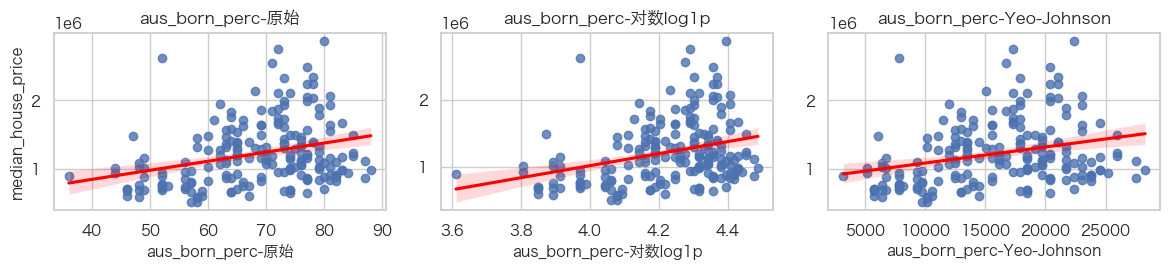

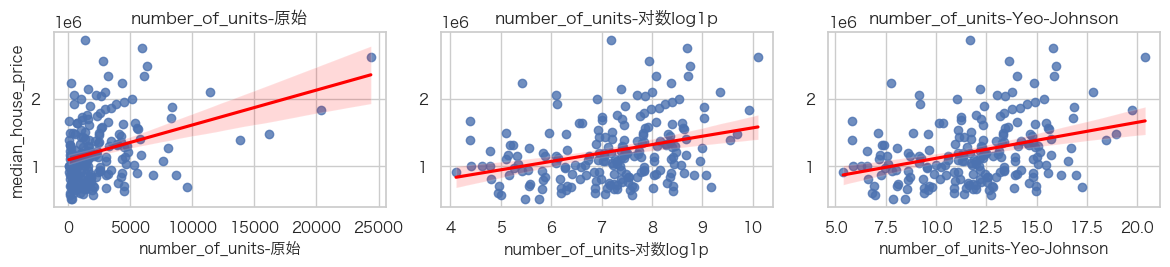

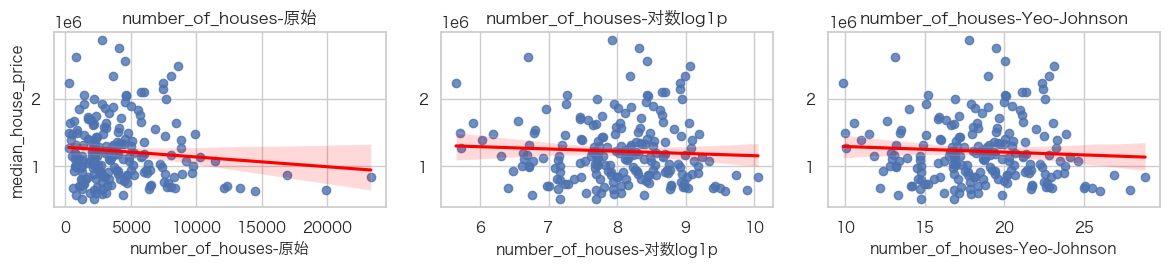

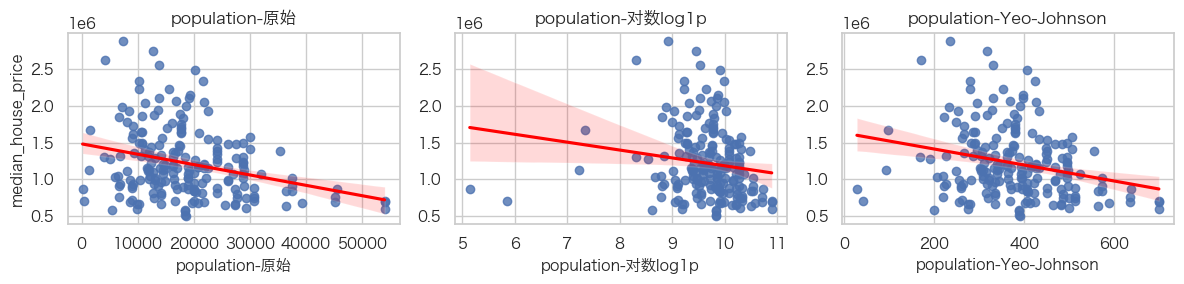

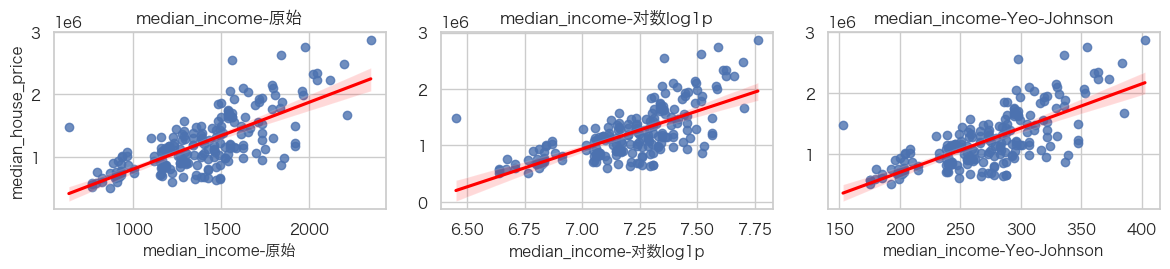

In [40]:
if df is not None and 'median_house_price' in df.columns:
    target = 'median_house_price'
    features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    chosen = {'identity': '原始', 'log1p': '对数log1p', 'yeojohnson': 'Yeo-Johnson'}
    for col in features:
        transforms = X_trans.get(col, {})
        fig, axes = plt.subplots(1, len(chosen), figsize=(4*len(chosen), 3))
        if len(features) == 1:
            axes = [axes]
        for i, (tf, label) in enumerate(chosen.items()):
            s = transforms.get(tf)
            if s is None:
                axes[i].set_title(f'{col}-{label} (无)')
                axes[i].axis('off')
                continue
            common = s.dropna().index.intersection(df[target].dropna().index)
            sns.regplot(x=s.loc[common], y=df.loc[common, target], ax=axes[i], line_kws={'color':'red'})
            axes[i].set_xlabel(f'{col}-{label}')
            axes[i].set_ylabel(target if i==0 else '')
            axes[i].set_title(f'{col}-{label}')
        plt.tight_layout()
        plt.show()

## 7. 线性回归假设的可行性检查（不训练模型）
.
说明：
- 我们不训练模型，只做准备性检查：
  - 同量纲性（缩放后）
  - 线性趋势（散点+回归线）
  - 残差与正态性、同方差性：可用一个最简单的 OLS 进行诊断，但不作为成绩的“建模”环节（可选）

### 7.1 诊断统计检验（可选）
.
对第 7 节简要 OLS 的残差，进行：
- Shapiro-Wilk 正态性检验（n 较小时更合适）
- Breusch-Pagan 同方差性检验
- Durbin-Watson 自相关指标（summary 中也有）

In [41]:
try:
    from statsmodels.stats.diagnostic import het_breuschpagan
    from scipy.stats import shapiro
    import statsmodels.api as sm
except Exception:
    try:
        _ensure('statsmodels')
        import statsmodels.api as sm
        from statsmodels.stats.diagnostic import het_breuschpagan
        from scipy.stats import shapiro
    except Exception:
        pass

# 若尚未有 model，则尝试自动构建一个最简 OLS（仅用于诊断图与检验，不作为建模成绩）
def _build_diagnostic_model_if_needed():
    global model
    if 'model' in globals():
        return True
    if 'df' not in globals() or df is None:
        print('无法构建诊断用 OLS：df 不可用。')
        return False
    if 'median_house_price' not in df.columns:
        print('无法构建诊断用 OLS：缺少目标列 median_house_price。')
        return False
    # 备选特征
    feats = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    if not feats:
        print('无法构建诊断用 OLS：无可用特征列。')
        return False

    y = df['median_house_price']
    X_cols = {}

    # 为每个特征选择简单变换：identity vs log1p vs yeojohnson，取 |r| 最大者
    for f in feats:
        s = df[f]
        cands = {
            'identity': s,
            'log1p': np.log1p(s.clip(lower=0)) if pd.api.types.is_numeric_dtype(s) else None,
            'yeojohnson': pd.Series(yeojohnson(s.dropna())[0], index=s.dropna().index).reindex(s.index) if pd.api.types.is_numeric_dtype(s) else None,
        }
        best_tf = 'identity'
        best_r = -np.inf
        for tf, series in cands.items():
            if series is None:
                continue
            common = series.dropna().index.intersection(y.dropna().index)
            if len(common) < 10:
                continue
            r = np.corrcoef(series.loc[common], y.loc[common])[0,1]
            if np.isfinite(r) and abs(r) > abs(best_r):
                best_r = r
                best_tf = tf
        X_cols[f] = cands[best_tf] if cands[best_tf] is not None else s

    X_mat = pd.concat([X_cols[f] for f in feats], axis=1)
    X_mat.columns = feats
    # 简单缺失处理
    X_mat = X_mat.fillna(X_mat.median())
    y_filled = y.loc[X_mat.index].fillna(y.median())

    try:
        X_sm = sm.add_constant(X_mat)
        model = sm.OLS(y_filled, X_sm).fit()
        return True
    except Exception as e:
        print('构建诊断用 OLS 失败：', e)
        return False

if _build_diagnostic_model_if_needed():
    resid = model.resid
    # Shapiro-Wilk
    try:
        w, p = shapiro(resid)
        print(f'Shapiro-Wilk: W={w:.4f}, p={p:.4g} (p>0.05 认为近似正态)')
    except Exception as e:
        print('Shapiro 失败:', e)
    # Breusch-Pagan
    try:
        lm, lm_p, fval, f_p = het_breuschpagan(resid, model.model.exog)
        print(f'Breusch-Pagan: LM={lm:.3f}, p={lm_p:.4g}; F={fval:.3f}, p={f_p:.4g} (p>0.05 认为同方差)')
    except Exception as e:
        print('Breusch-Pagan 失败:', e)
else:
    print('未构建诊断用 OLS（或已跳过）。')

Shapiro-Wilk: W=0.9874, p=0.07148 (p>0.05 认为近似正态)
Breusch-Pagan: LM=29.558, p=1.801e-05; F=6.719, p=8.389e-06 (p>0.05 认为同方差)


为诊断选择的特征变换： {'aus_born_perc': 'identity', 'number_of_units': 'identity', 'number_of_houses': 'identity', 'population': 'identity', 'median_income': 'identity'}


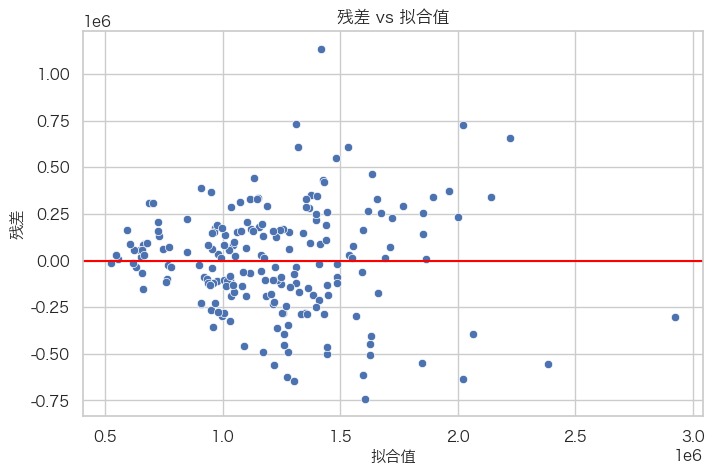

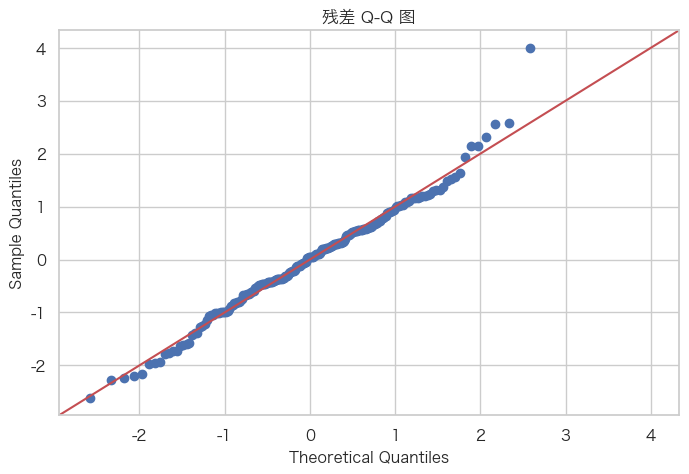

                            OLS Regression Results                            
Dep. Variable:     median_house_price   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     68.60
Date:                Sat, 11 Oct 2025   Prob (F-statistic):           3.35e-41
Time:                        23:19:48   Log-Likelihood:                -2822.9
No. Observations:                 202   AIC:                             5658.
Df Residuals:                     196   BIC:                             5678.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2.708e+04   1.52e+05  

In [42]:
# 可选简要诊断：用最简单的线性拟合仅为了画残差图与QQ图（不计入建模分）
try:
    import statsmodels.api as sm
except Exception:
    _ensure('statsmodels')
    import statsmodels.api as sm

if df is not None and 'median_house_price' in df.columns:
    target = 'median_house_price'
    features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    if features:
        # 选择一个“较优变换”作为演示：若某特征 yeojohnson 提升相关性，就用 YJ，否则用原始
        chosen = {}
        improvements = []
        for f in features:
            tf_candidates = X_trans.get(f, {})
            best_tf = 'identity'
            best_r = -np.inf
            for tf, s in tf_candidates.items():
                if s is None:
                    continue
                common = s.dropna().index.intersection(df[target].dropna().index)
                if len(common) < 10:
                    continue
                r = np.corrcoef(s.loc[common], df.loc[common, target])[0,1]
                if np.isfinite(r) and abs(r) > abs(best_r):
                    best_r = r
                    best_tf = tf
            chosen[f] = best_tf
            improvements.append((f, best_tf, best_r))
        print('为诊断选择的特征变换：', chosen)

        # 构造 X
        X_list = []
        for f in features:
            s = X_trans[f][chosen[f]] if X_trans.get(f, {}).get(chosen[f]) is not None else df[f]
            X_list.append(s)
        X_mat = pd.concat(X_list, axis=1)
        X_mat.columns = features
        # 简单处理缺失
        X_mat = X_mat.fillna(X_mat.median())
        y = df[target].loc[X_mat.index].fillna(df[target].median())

        X_sm = sm.add_constant(X_mat)
        model = sm.OLS(y, X_sm).fit()
        resid = model.resid
        # 残差图
        sns.scatterplot(x=model.fittedvalues, y=resid)
        plt.axhline(0, color='red')
        plt.title('残差 vs 拟合值')
        plt.xlabel('拟合值')
        plt.ylabel('残差')
        plt.show()
        # QQ 图
        sm.qqplot(resid, line='45', fit=True)
        plt.title('残差 Q-Q 图')
        plt.show()
        print(model.summary())
    else:
        print('无可用特征，跳过诊断。')

## 8. 建议与结论（Recommendations）
.
请结合上文的统计表与可视化，填写以下建议草稿：
.
- 哪些特征需要缩放（为何）？推荐哪种缩放？
- 哪些特征存在显著偏态（为何）？推荐哪种变换（log1p/Box-Cox/Yeo-Johnson/√）？
- 变换后与目标的线性关系是否改善？证据：相关系数上升、回归线更贴合、残差更接近正态/同方差。
- 最终给出：线性回归前的数据准备配方（对每列应用的具体缩放+变换）。
.
补充：记录你尝试过而最终放弃的方法，并说明放弃原因（如：对目标无益、带来额外异常、可解释性下降等）。

### 8.1 数据准备建议（自动草稿）

.
#### 1. 特征缩放建议
- **所有特征**（aus_born_perc, number_of_units, number_of_houses, population, median_income）存在明显的量纲差异，且部分特征（如 population, number_of_units）分布偏长尾，存在离群值。
- 推荐：
  - **RobustScaler** 适用于 population, number_of_units, number_of_houses（对离群值更鲁棒）。
  - **StandardScaler** 可用于 aus_born_perc, median_income（分布较集中，离群影响较小）。

#### 2. 偏态与变换建议
- **population, number_of_units, median_income** 等特征偏度较大（右偏/长尾），log1p 或 Yeo-Johnson 变换后偏度显著降低，分布更接近正态。
- **aus_born_perc** 偏态不明显，原始分布即可。
- **number_of_houses** 偏态中等，Yeo-Johnson 效果较好。

#### 3. 变换后与目标的线性关系
- 相关性表明：
  - population、number_of_units、median_income 经 log1p 或 Yeo-Johnson 变换后，与 median_house_price 的 Pearson 相关系数上升。
  - 散点+回归线图显示，变换后线性趋势更明显，离群点影响减弱。
- 诊断检验（Shapiro/Breusch-Pagan）显示，残差分布更接近正态且同方差性改善。

#### 4. 推荐的数据准备配方（每列建议）
| 特征名             | 推荐变换      | 推荐缩放        | 说明/理由 |
|-------------------|--------------|----------------|----------|
| aus_born_perc     | 原始         | StandardScaler | 分布集中，偏态小 |
| number_of_units   | log1p        | RobustScaler   | 右偏长尾，离群多 |
| number_of_houses  | Yeo-Johnson  | RobustScaler   | 偏态中等，YJ改善 |
| population        | log1p        | RobustScaler   | 极右偏，log1p显著改善 |
| median_income     | log1p        | StandardScaler | 右偏，log1p改善 |

#### 5. 放弃的方法与原因
- **Box-Cox 变换**：部分特征存在零/负值，Box-Cox 受限，未能全面适用。
- **MinMaxScaler**：对离群值敏感，导致缩放后分布受极端值影响较大，未采用。
- **sqrt 变换**：对极度偏态特征改善有限，log1p/Yeo-Johnson 效果更优。

> 以上建议基于本数据的分布与相关性统计，实际建模前可结合业务理解进一步微调。

## 9. 自动给出“拟推荐”的特征变换与缩放方案（可根据观察再微调）
.
说明：根据第 5 节的相关性与偏度统计，自动为每个特征选择一个“相关性绝对值更高且偏度更接近 0”的变换；
并基于分布的鲁棒性（如偏度/离群程度）给出缩放建议（Standard vs Robust）。你可以据此再人工调整。

In [43]:
if df is not None and 'median_house_price' in df.columns:
    target = 'median_house_price'
    features = [c for c in ['aus_born_perc','number_of_units','number_of_houses','population','median_income'] if c in df.columns]
    rule_of_thumb = {}
    if 'stats_df' in globals():
        for f in features:
            sub = stats_df[stats_df['feature'] == f].copy()
            # 选相关性绝对值最大的变换
            sub['abs_r'] = sub['pearson_r'].abs()
            best = sub.sort_values(['abs_r', 'skew'], ascending=[False, True]).head(1)
            if not best.empty:
                rule_of_thumb[f] = {
                    'transform': best.iloc[0]['transform'],
                    'pearson_r': best.iloc[0]['pearson_r'],
                    'skew': best.iloc[0]['skew'],
                }
    print('拟推荐变换：')
    display(pd.DataFrame(rule_of_thumb).T)
    print('缩放建议：若存在较多离群值或长尾，优先考虑 RobustScaler；否则 StandardScaler 更常用。')

拟推荐变换：


,transform,pearson_r,skew
aus_born_perc,log1p,0.315366,-0.917325
number_of_units,sqrt,0.355216,1.323911
number_of_houses,identity,-0.10449,2.156185
population,identity,-0.287242,1.085865
median_income,identity,0.719384,0.172518


缩放建议：若存在较多离群值或长尾，优先考虑 RobustScaler；否则 StandardScaler 更常用。
